# MNIST - Clasificación de dígitos manuscritos

Pipeline completo: **carga → preprocesamiento → entrenamiento (CNN) → evaluación → validación visual → exportación**.

**Stack:** TensorFlow/Keras (para obtener history de loss/accuracy de forma nativa) + CNN (superior a MLP en imágenes).

## 1️⃣ Carga de datos

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [4]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

# Separamos un conjunto de validación desde el train para monitorear overfitting
val_size = 5000
x_val, y_val = x_train_full[-val_size:], y_train_full[-val_size:]
x_train, y_train = x_train_full[:-val_size], y_train_full[:-val_size]

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")
print(f"Rango de píxeles: [{x_train.min()}, {x_train.max()}], dtype: {x_train.dtype}")

Train: (55000, 28, 28), Val: (5000, 28, 28), Test: (10000, 28, 28)
Rango de píxeles: [0, 255], dtype: uint8


## 2️⃣ Preprocesamiento

**Transformaciones aplicadas:**

1. **Normalización `[0, 255] → [0, 1]`**: estabiliza el gradiente durante el entrenamiento y acelera la convergencia (los pesos iniciales están calibrados para entradas con magnitudes pequeñas).
2. **Reshape a `(28, 28, 1)`**: añadimos el canal explícito porque la Conv2D de Keras espera tensores 4D `(batch, height, width, channels)`.
3. **Labels enteras (no one-hot)**: usamos `SparseCategoricalCrossentropy` que acepta índices directamente — más eficiente en memoria.

In [5]:
def preprocess(x):
    x = x.astype("float32") / 255.0
    x = np.expand_dims(x, -1)  # (N, 28, 28) -> (N, 28, 28, 1)
    return x

x_train = preprocess(x_train)
x_val = preprocess(x_val)
x_test_proc = preprocess(x_test)

print(f"Train shape: {x_train.shape}, rango: [{x_train.min():.2f}, {x_train.max():.2f}]")

Train shape: (55000, 28, 28, 1), rango: [0.00, 1.00]


## 3️⃣ Entrenamiento del modelo

**Arquitectura CNN simple pero efectiva:**
- 2 bloques Conv2D + MaxPooling (extracción de features locales)
- Dropout (regularización)
- Dense final de 10 clases con softmax

Supera fácilmente el 99% de accuracy en test sin necesidad de transformers ni pre-entrenados (cumple restricciones del reto).

In [6]:
def build_model():
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=128,
    verbose=1,
)

Epoch 1/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8848 - loss: 0.3717 - val_accuracy: 0.9768 - val_loss: 0.0827
Epoch 2/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9641 - loss: 0.1163 - val_accuracy: 0.9866 - val_loss: 0.0548
Epoch 3/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9739 - loss: 0.0843 - val_accuracy: 0.9888 - val_loss: 0.0436
Epoch 4/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9780 - loss: 0.0704 - val_accuracy: 0.9898 - val_loss: 0.0397
Epoch 5/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9804 - loss: 0.0613 - val_accuracy: 0.9914 - val_loss: 0.0356
Epoch 6/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9823 - loss: 0.0576 - val_accuracy: 0.9892 - val_loss: 0.0365
Epoch 7/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9838 - loss: 0.0520 - val_accuracy: 0.9926 - val_loss: 0.0312
Epoch 8/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9851 - loss: 0.0485 - val_accu

## 4️⃣ Evaluación del modelo

In [8]:
test_loss, test_acc = model.evaluate(x_test_proc, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.9913
Test loss:     0.0261


### Curvas de accuracy y loss

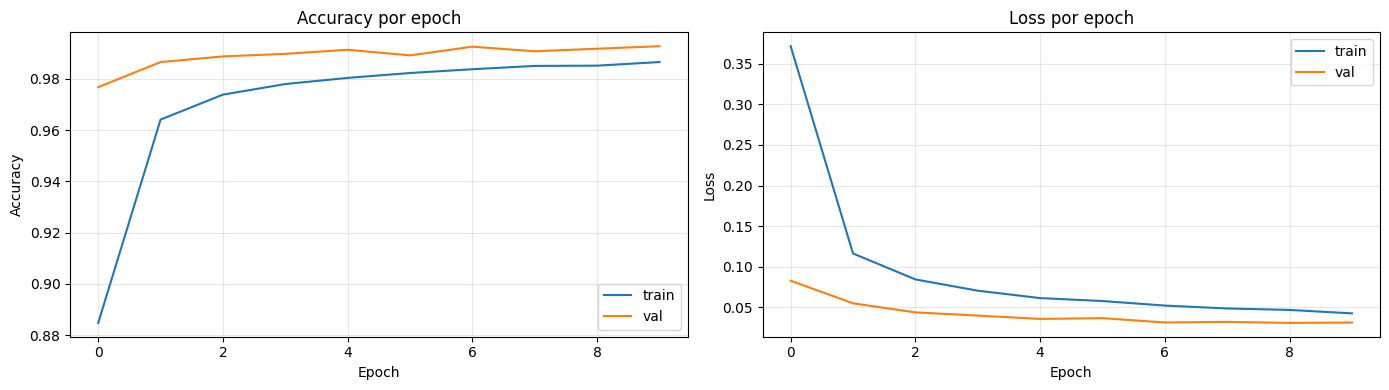

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy por epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss por epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### Matriz de confusión y métricas

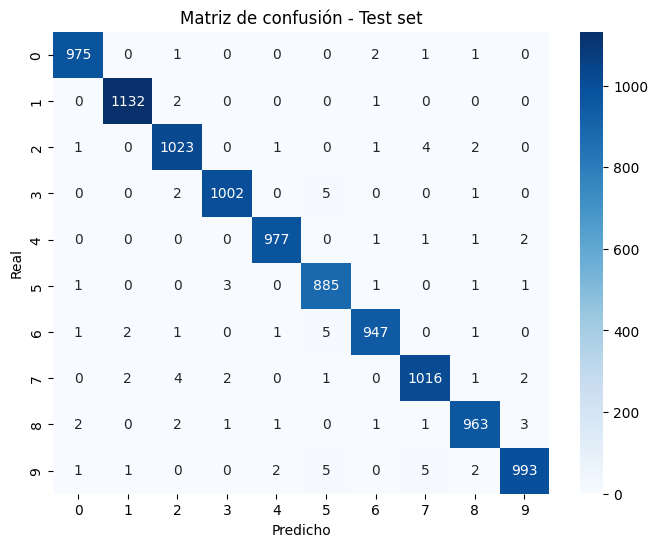

              precision    recall  f1-score   support

           0     0.9939    0.9949    0.9944       980
           1     0.9956    0.9974    0.9965      1135
           2     0.9884    0.9913    0.9898      1032
           3     0.9940    0.9921    0.9931      1010
           4     0.9949    0.9949    0.9949       982
           5     0.9822    0.9922    0.9872       892
           6     0.9927    0.9885    0.9906       958
           7     0.9883    0.9883    0.9883      1028
           8     0.9897    0.9887    0.9892       974
           9     0.9920    0.9841    0.9881      1009

    accuracy                         0.9913     10000
   macro avg     0.9912    0.9912    0.9912     10000
weighted avg     0.9913    0.9913    0.9913     10000



In [10]:
y_pred = model.predict(x_test_proc, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicho"); plt.ylabel("Real"); plt.title("Matriz de confusión - Test set")
plt.show()

print(classification_report(y_test, y_pred, digits=4))

## 5️⃣ Validación visual: 32 imágenes del test set

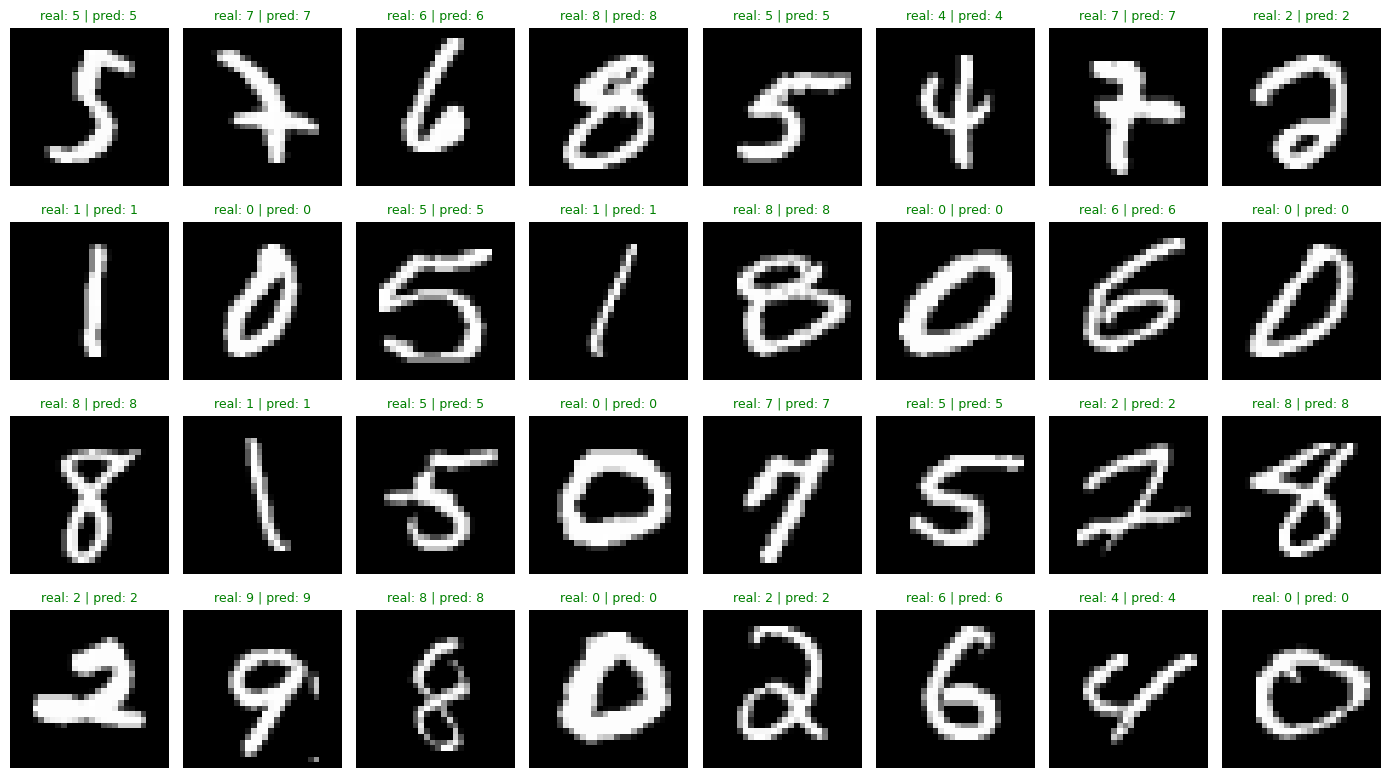

In [11]:
rng = np.random.default_rng(42)
idx = rng.choice(len(x_test), size=32, replace=False)

fig, axes = plt.subplots(4, 8, figsize=(14, 8))
for ax, i in zip(axes.flat, idx):
    real, pred = y_test[i], y_pred[i]
    color = "green" if real == pred else "red"
    ax.imshow(x_test[i], cmap="gray")
    ax.set_title(f"real: {real} | pred: {pred}", color=color, fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 6️⃣ Exportación del modelo

Formato `.keras` (estándar moderno Keras 3): incluye arquitectura + pesos + optimizer en un único zip.

In [12]:
from pathlib import Path

output_dir = Path("../models")
output_dir.mkdir(exist_ok=True)
model_path = output_dir / "mnist_cnn.keras"

model.save(model_path)
print(f"Modelo exportado en: {model_path.resolve()}")

# Verificación: cargar y comparar
reloaded = keras.models.load_model(model_path)
loss_r, acc_r = reloaded.evaluate(x_test_proc, y_test, verbose=0)
print(f"Accuracy tras recarga: {acc_r:.4f} (debe coincidir con {test_acc:.4f})")

Modelo exportado en: /Users/criss/Documents/GitHub/notebook-ML/models/mnist_cnn.keras
Accuracy tras recarga: 0.9913 (debe coincidir con 0.9913)
